# SA Overview — Most Illustrated Subjects Across All SA Notebooks

**Questions:**
1. Which CKs are most illustrated (images & books) over time?
2. Where are they illustrated (place / place_category)?
3. Which CKs tend to appear together in the same books?


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations
import warnings; warnings.filterwarnings('ignore')


## 2. Load data


In [2]:
df    = pd.read_csv('full_image_data_feb_25.csv')
books = pd.read_csv('full_book_data_feb_25.csv')
df['printer']   = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

# All CKs studied across SA notebooks (from SA_1.1 → SA_5)
SA_CKS = [
    # SA 1 — Sphere definition & nested spheres
    'CK_Definition of Sphere by Theodosius','CK_Definition of Sphere by Euclid',
    'CK_Additions on Definitions of the Sphere',
    'CK_07 Spheres','CK_08 Spheres','CK_09 Spheres',
    'CK_10 Spheres','CK_11 Spheres','CK_12 Spheres',
    'CK_Right and Oblique Sphere','CK_Terraqueous Globe','CK_T-O Maps',
    'CK_Structure of the Sublunar World','CK_Sphericity of the Heavens',
    'CK_Sphericity of the Water Element','CK_Sphericity of the Earth',
    'CK_Centrality of Earth','CK_Isoperimetry','CK_Geometry for Geometry',
    'CK_Relation Between the Spheres of Water and Earth',
    # SA 2 — Circles & zones
    'CK_Equinoctial','CK_Tropics','CK_Colures','CK_Parallels',
    'CK_Five Zones','CK_Seven Climate Zones','CK_Horizon',
    'CK_Zodiac','CK_Sun in Sign','CK_Signs of the Zodiac',
    'CK_Ascensions in the Right and Oblique Sphere',
    'CK_Relations between Arcs of the Zodiac and the Equinoctial',
    'CK_Circles of Natural Days','CK_Elevation of the Pole',
    'CK_Positions of the Zenith','CK_Sun Lines and Motion',
    # SA 3 — Solar motion
    'CK_Sun Orbit','CK_Apparent Size of Stars','CK_Lunar Nodes',
    'CK_Circles of Equant Deferent Epicycle',
    'CK_Stationary and Retrograde Motion',
    # SA 4 — Eclipses & instruments
    'CK_Lunar Eclipse','CK_Solar Eclipse',
    'CK_Negligible Dimensions of the Earth',
    # SA 5 — Instruments
    'CK_Astrolabe','CK_Armillary Sphere','CK_Volvelles',
    'CK_Quadrant','CK_Sundial',
]

# Keep only CKs present in the data
SA_CKS = [c for c in SA_CKS if c in df['cks'].unique()]
sa_df  = df[df['cks'].isin(SA_CKS)].copy()

print(f'CKs loaded : {len(SA_CKS)}')
print(f'Rows       : {len(sa_df)}')
print(f'Books      : {sa_df["bid"].nunique()}')
print(f'Images     : {sa_df["images"].nunique()}')


CKs loaded : 48
Rows       : 17291
Books      : 323
Images     : 13779


## 3. Overall ranking — images & books per CK


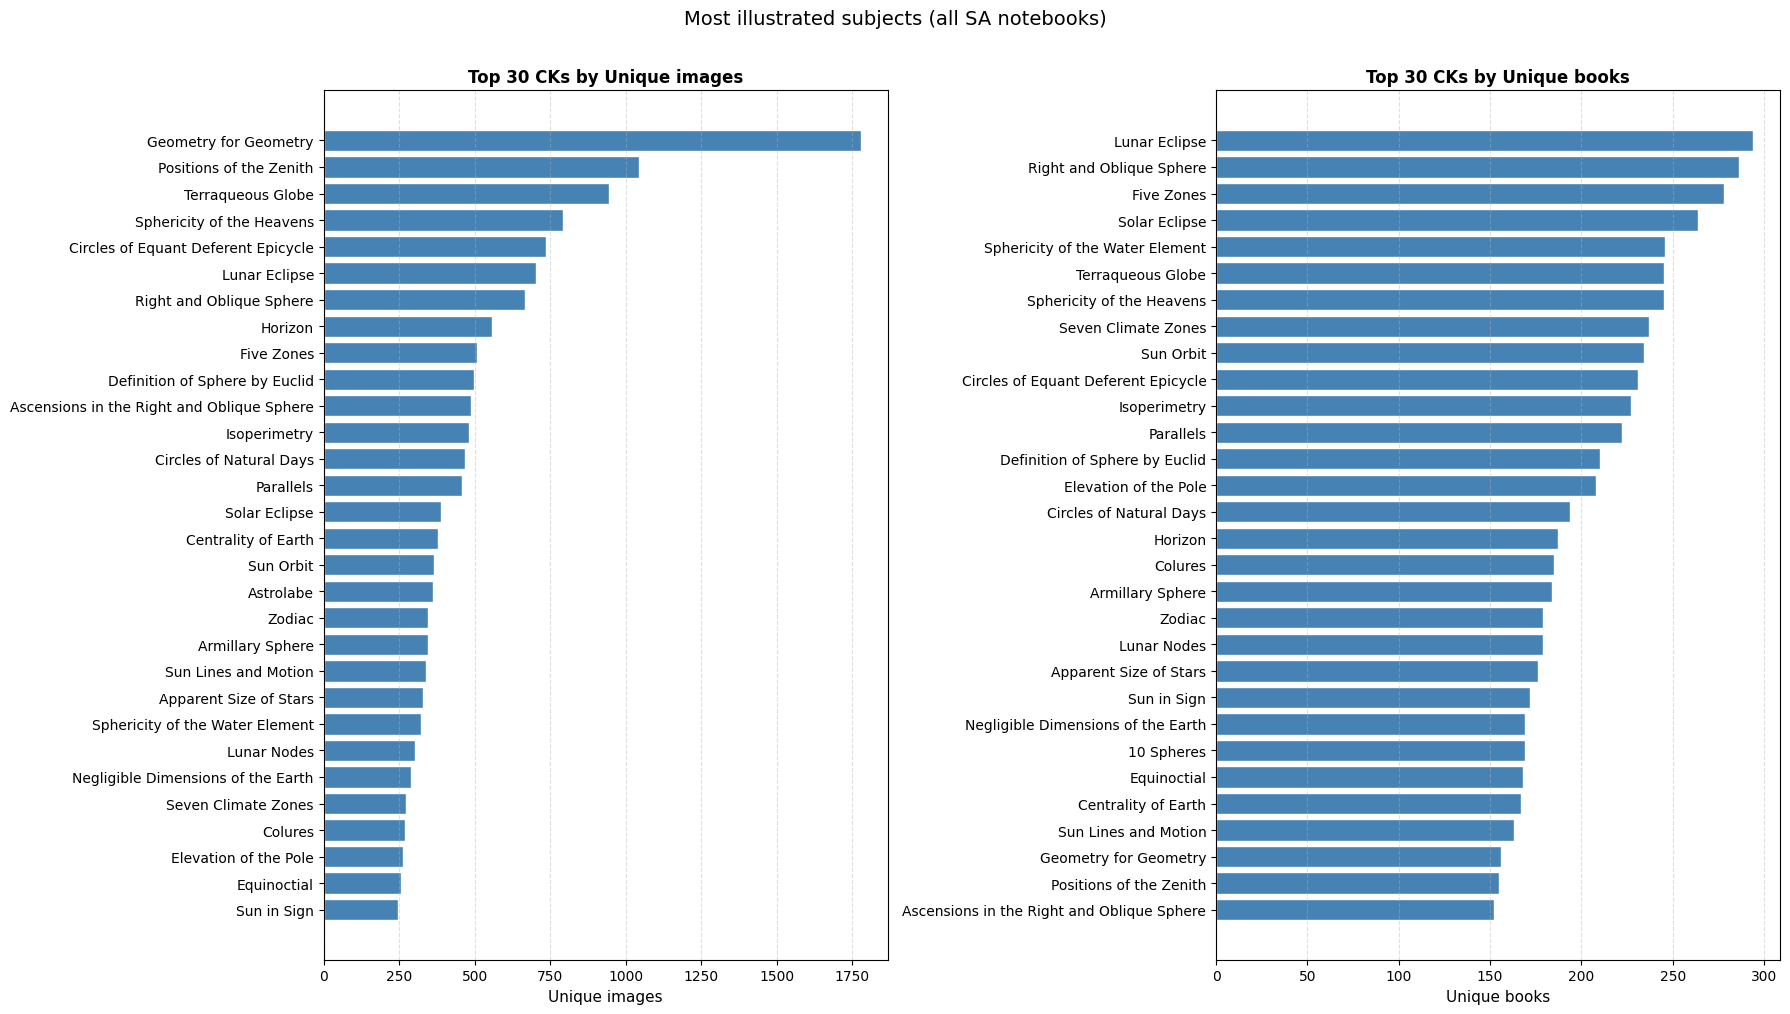

,cks,n_images,n_books
0,CK_Geometry for Geometry,1778,156
1,CK_Positions of the Zenith,1045,155
2,CK_Terraqueous Globe,946,245
3,CK_Sphericity of the Heavens,791,245
4,CK_Circles of Equant Deferent Epicycle,736,231
5,CK_Lunar Eclipse,704,294
6,CK_Right and Oblique Sphere,667,286
7,CK_Horizon,557,187
8,CK_Five Zones,508,278
9,CK_Definition of Sphere by Euclid,498,210


In [3]:
ck_stats = (
    sa_df.groupby('cks')
    .agg(n_images=('images','nunique'), n_books=('bid','nunique'))
    .sort_values('n_images', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
for ax, col, label in zip(axes,
        ['n_images','n_books'], ['Unique images','Unique books']):
    top = ck_stats.nlargest(30, col)
    short = top['cks'].str.replace('CK_','')
    ax.barh(short[::-1], top[col][::-1], color='steelblue', edgecolor='white')
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(f'Top 30 CKs by {label}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.suptitle('Most illustrated subjects (all SA notebooks)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('SA_overview_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
display(ck_stats)


## 4. Illustration frequency over time

A heatmap: rows = CKs (sorted by total images), columns = 20-year periods, cells = unique images.


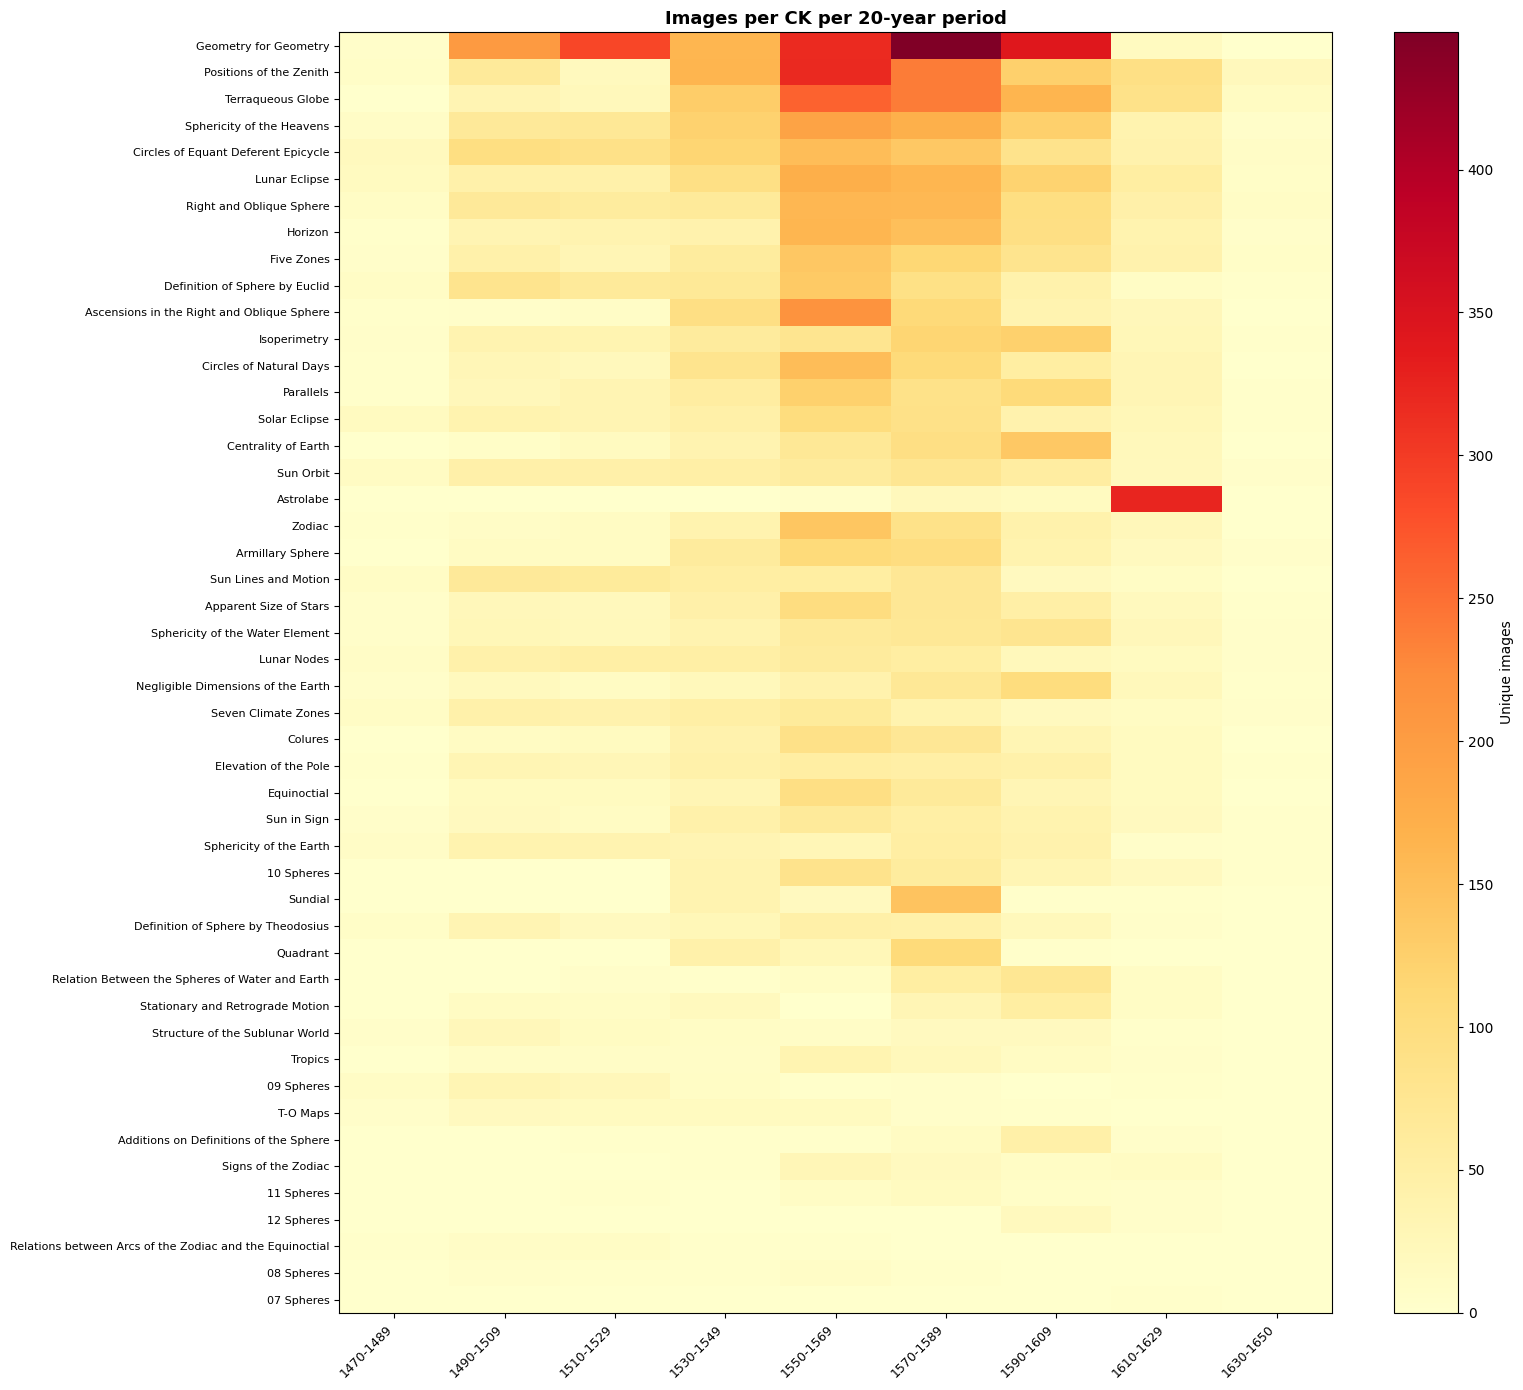

In [4]:
pivot = (
    sa_df.groupby(['cks','year_interval'])['images']
    .nunique().unstack(fill_value=0)
)
# order rows by total
pivot = pivot.loc[ck_stats['cks']]
pivot.index = pivot.index.str.replace('CK_','')

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Unique images')
ax.set_title('Images per CK per 20-year period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('SA_overview_heatmap_time.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Top CKs by place category


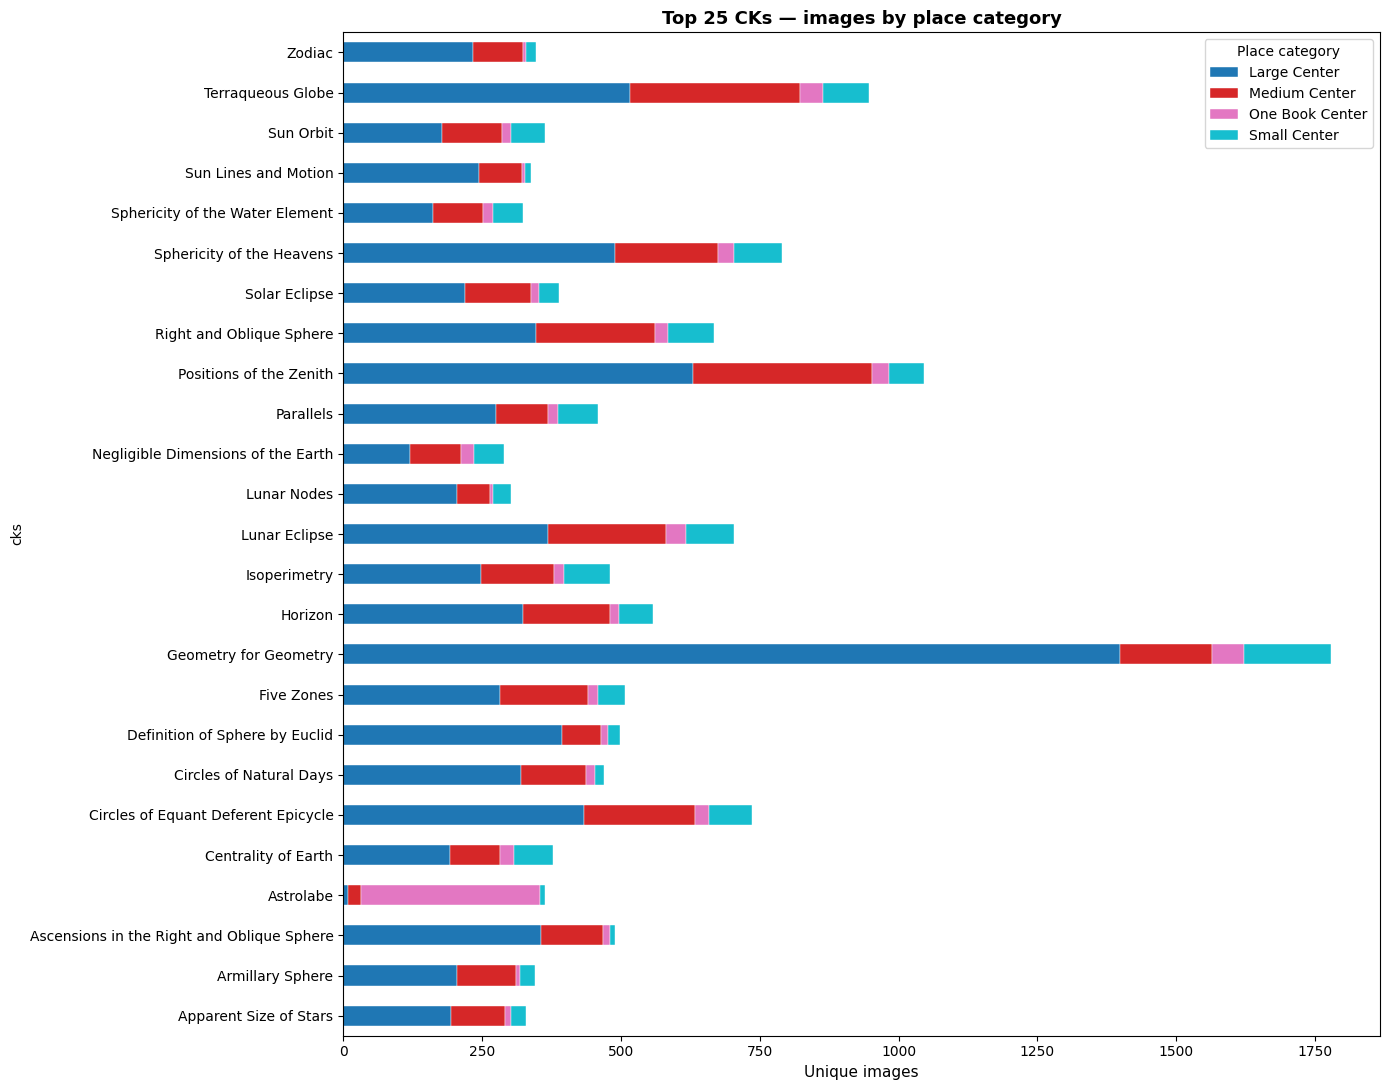

In [5]:
place_pivot = (
    sa_df.groupby(['cks','place_category'])['images']
    .nunique().unstack(fill_value=0)
)
place_pivot = place_pivot.loc[
    place_pivot.index.isin(ck_stats['cks'])]
place_pivot.index = place_pivot.index.str.replace('CK_','')
# keep top 25 CKs
top25 = ck_stats.head(25)['cks'].str.replace('CK_','')
place_pivot = place_pivot.loc[place_pivot.index.isin(top25)]

place_pivot.plot(
    kind='barh', stacked=True, figsize=(14, 11),
    colormap='tab10', edgecolor='white', linewidth=0.3
)
plt.xlabel('Unique images', fontsize=11)
plt.title('Top 25 CKs — images by place category', fontsize=13, fontweight='bold')
plt.legend(title='Place category', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig('SA_overview_by_place.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. CK co-occurrence network

Nodes = CKs. An edge means two CKs appear in the same book; edge weight = number of books.
Thicker / darker edges = more books share both CKs.


Nodes: 47  Edges (>=5 books): 978


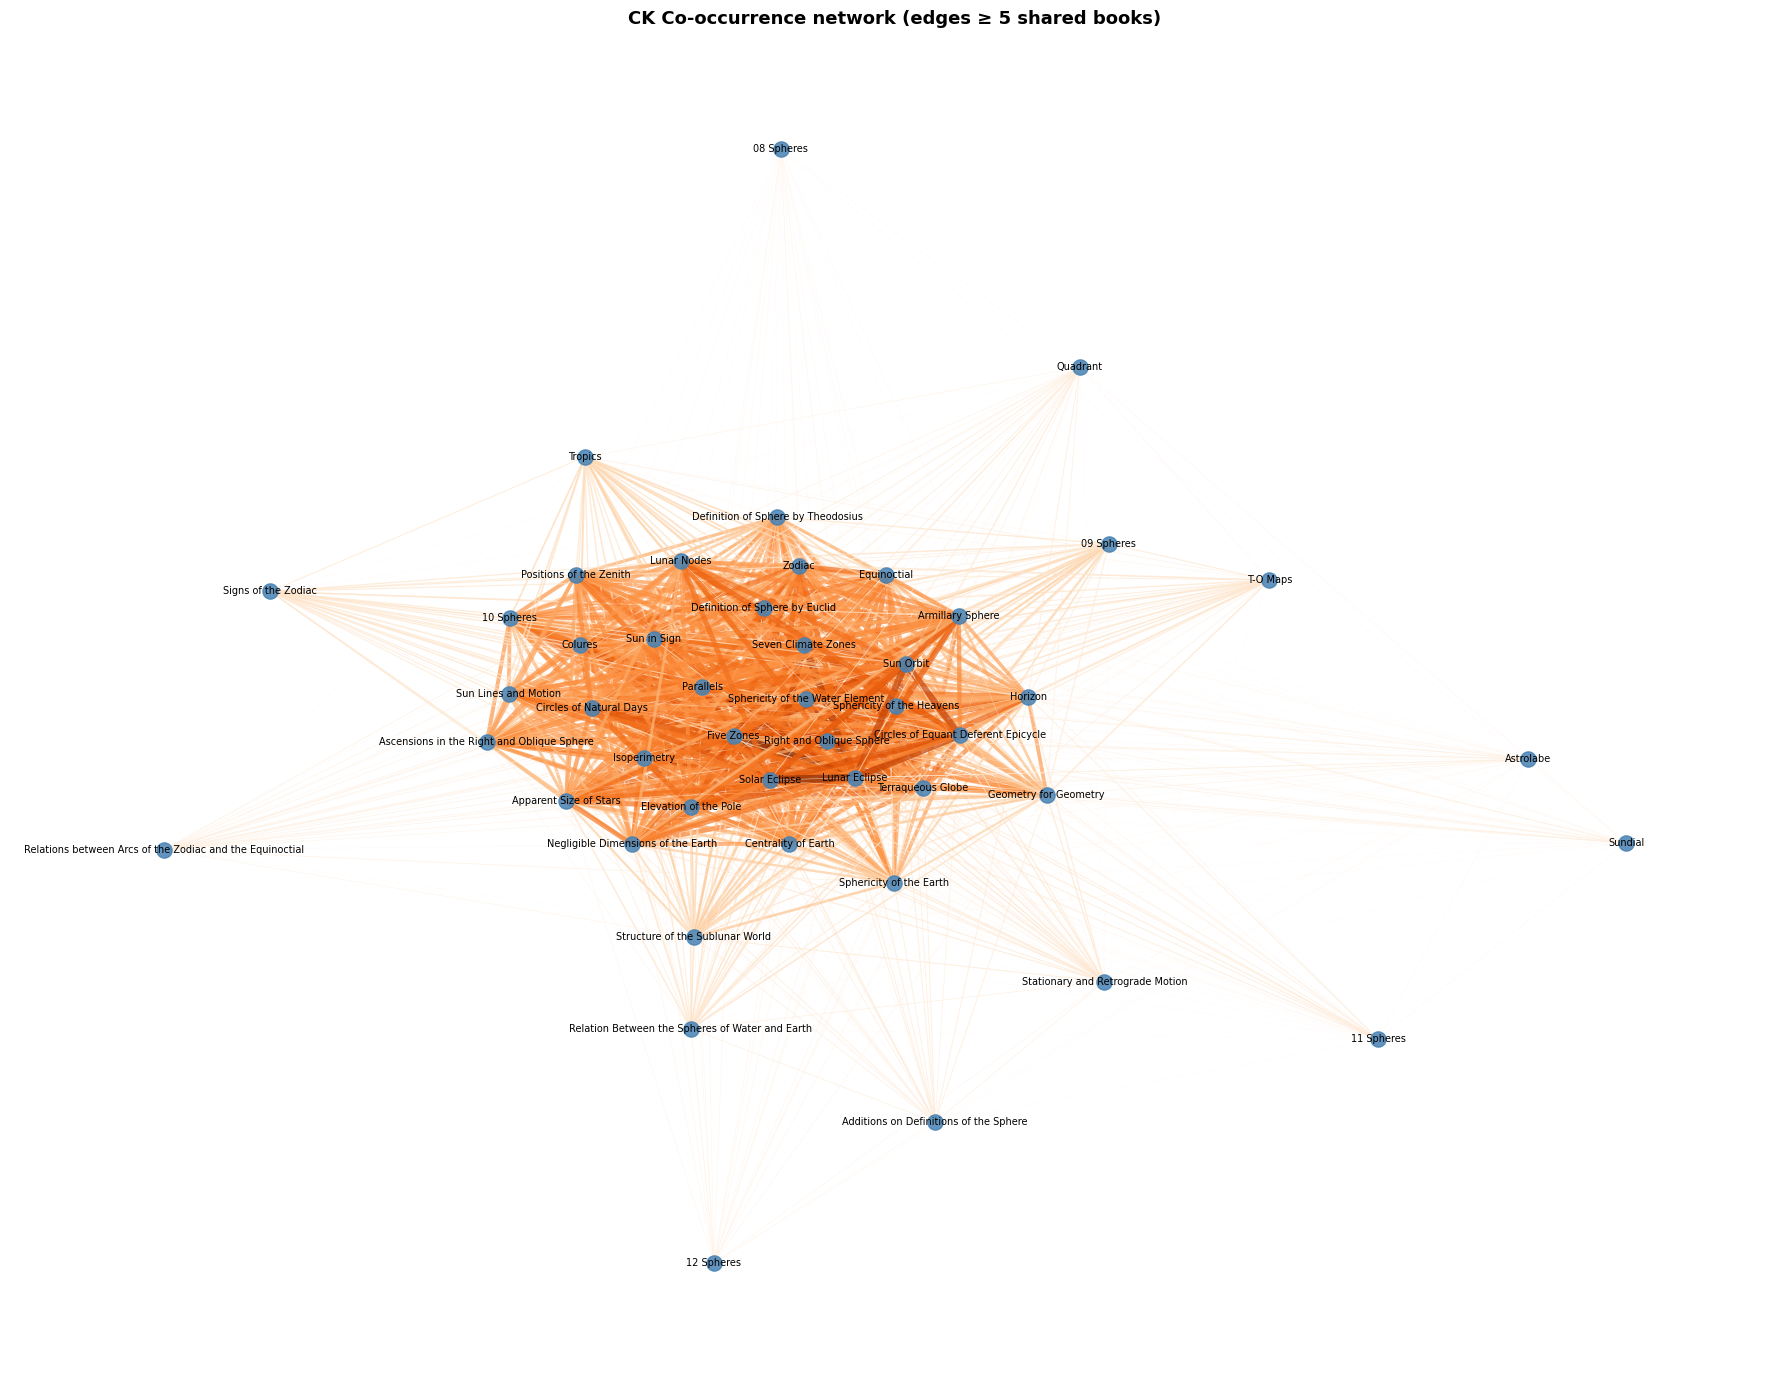

In [6]:
# Build co-occurrence matrix
book_cks = (
    sa_df.groupby('bid')['cks']
    .apply(lambda x: list(x.unique()))
)

cooc = {}
for cks_list in book_cks:
    for a, b in combinations(cks_list, 2):
        key = tuple(sorted([a, b]))
        cooc[key] = cooc.get(key, 0) + 1

# Build graph — only edges with >= 5 books
THRESHOLD = 5
G = nx.Graph()
G.add_nodes_from(SA_CKS)
for (a, b), w in cooc.items():
    if w >= THRESHOLD:
        G.add_edge(a, b, weight=w)

# Remove isolates
G.remove_nodes_from(list(nx.isolates(G)))

print(f'Nodes: {G.number_of_nodes()}  Edges (>={THRESHOLD} books): {G.number_of_edges()}')

weights = [G[u][v]['weight'] for u,v in G.edges()]
pos = nx.spring_layout(G, seed=42, k=1.8)

fig, ax = plt.subplots(figsize=(18, 14))
nx.draw_networkx_nodes(G, pos, node_size=120, node_color='steelblue',
                       alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos,
    width=[w/max(weights)*6 for w in weights],
    edge_color=weights, edge_cmap=plt.cm.Oranges,
    alpha=0.7, ax=ax)
nx.draw_networkx_labels(G, pos,
    labels={n: n.replace('CK_','') for n in G.nodes()},
    font_size=7, ax=ax)
ax.set_title(f'CK Co-occurrence network (edges ≥ {THRESHOLD} shared books)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('SA_overview_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Most frequently co-occurring CK pairs


In [7]:
pairs_df = (
    pd.DataFrame([(a, b, w) for (a,b),w in cooc.items()],
                 columns=['CK_A','CK_B','n_books'])
    .sort_values('n_books', ascending=False)
    .reset_index(drop=True)
)
pairs_df['CK_A'] = pairs_df['CK_A'].str.replace('CK_','')
pairs_df['CK_B'] = pairs_df['CK_B'].str.replace('CK_','')
display(pairs_df.head(40))


,CK_A,CK_B,n_books
0,Lunar Eclipse,Right and Oblique Sphere,268
1,Five Zones,Right and Oblique Sphere,265
2,Five Zones,Lunar Eclipse,265
3,Lunar Eclipse,Solar Eclipse,256
4,Right and Oblique Sphere,Solar Eclipse,241
5,Right and Oblique Sphere,Sphericity of the Water Element,240
6,Five Zones,Solar Eclipse,240
7,Five Zones,Sphericity of the Water Element,236
8,Lunar Eclipse,Sphericity of the Water Element,235
9,Lunar Eclipse,Terraqueous Globe,234
